In [111]:
# Import Necessary Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler

import warnings
warnings.filterwarnings("ignore")

In [ ]:
#Load and view data
df = pd.read_csv("uber.csv")
df.head()

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,52:06.0,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,04:56.0,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,45:00.0,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,22:21.0,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,47:00.0,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


### *Basic Data Inspection*

In [113]:
df.shape

(200000, 9)

In [114]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         200000 non-null  int64  
 1   key                200000 non-null  object 
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  object 
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 13.7+ MB


In [115]:
df.describe()

,Unnamed: 0,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,2.000000e+05,200000.000000,200000.000000,200000.000000,199999.000000,199999.000000,200000.000000
mean,2.771250e+07,11.359955,-72.527638,39.935885,-72.525292,39.923890,1.684535
std,1.601382e+07,9.901776,11.437787,7.720539,13.117408,6.794829,1.385997
min,1.000000e+00,-52.000000,-1340.648410,-74.015515,-3356.666300,-881.985513,0.000000
25%,1.382535e+07,6.000000,-73.992065,40.734796,-73.991407,40.733823,1.000000
50%,2.774550e+07,8.500000,-73.981823,40.752592,-73.980093,40.753042,1.000000
75%,4.155530e+07,12.500000,-73.967153,40.767158,-73.963659,40.768001,2.000000
max,5.542357e+07,499.000000,57.418457,1644.421482,1153.572603,872.697628,208.000000


In [116]:
df.isnull().sum()

Unnamed: 0           0
key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    1
dropoff_latitude     1
passenger_count      0
dtype: int64

In [117]:
df.dropna(inplace= True)

In [118]:
df.shape

(199999, 9)

In [119]:
df.duplicated().sum()

0

### *Data Cleaning*

In [120]:
# Converting date column to datetime format

df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'], errors='coerce')

In [121]:
# Check how many invalid datetime entries
print(df['pickup_datetime'].isna().sum())


0


In [122]:
df[df['fare_amount'] <= 0]

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
20744,25344154,25:07.0,0.00,2015-04-22 23:25:07+00:00,-73.658897,40.805199,-73.658897,40.805199,1
22182,22994576,59:51.0,0.00,2010-03-20 02:59:51+00:00,-73.994366,40.755395,-73.998718,40.854853,2
63395,30260042,07:41.0,-5.00,2015-03-03 23:07:41+00:00,-73.992249,40.748936,-73.988518,40.748180,1
71246,51325304,47:10.0,-3.30,2010-02-11 21:47:10+00:00,-73.952725,40.768235,-73.949928,40.772208,2
79903,50284253,43:02.0,-3.50,2015-05-01 14:43:02+00:00,-73.982429,40.775024,-73.981750,40.778439,1
87467,10649069,51:13.0,0.00,2015-01-04 03:51:13+00:00,-73.969475,40.807503,0.000000,0.000000,2
89322,26673143,26:10.0,-49.57,2010-03-09 08:26:10+00:00,-73.972772,40.785657,-73.972867,40.785500,5
92063,10267585,49:10.0,-23.70,2010-03-12 08:49:10+00:00,-73.952740,40.768233,-74.007028,40.707338,3
98875,51135168,31:14.0,-52.00,2015-03-20 21:31:14+00:00,-74.000359,40.728729,-74.005699,40.728680,5
104080,21688700,25:10.0,-7.30,2010-03-09 20:25:10+00:00,-73.952623,40.766942,-73.953787,40.784882,1


In [123]:
# Drop rows with invalid fare values (negative or zero)
df = df[df['fare_amount'] > 0]

In [124]:
# Dropping unwanted columns
df.drop(columns= ['Unnamed: 0', 'key'], inplace= True)

In [125]:
# Check for zero latitude/longitude
zero_lat = (df['pickup_latitude'] == 0) | (df['dropoff_latitude'] == 0)
zero_lon = (df['pickup_longitude'] == 0) | (df['dropoff_longitude'] == 0)

print("Rows with zero latitude:", zero_lat.sum())
print("Rows with zero longitude:", zero_lon.sum())

Rows with zero latitude: 3950
Rows with zero longitude: 3960


In [126]:
# Drop rows with invalid coordinates
df = df[~(zero_lat | zero_lon)]

In [127]:
df = df[(df['pickup_latitude'].between(-90, 90)) &
        (df['dropoff_latitude'].between(-90, 90)) &
        (df['pickup_longitude'].between(-180, 180)) &
        (df['dropoff_longitude'].between(-180, 180))]

In [128]:
df['passenger_count'].value_counts()

1      135624
2       28862
5       13738
3        8705
6        4202
4        4182
0         686
208         1
Name: passenger_count, dtype: int64

In [129]:
# Remove unrealistic passenger counts
df = df[(df['passenger_count'] > 0) & (df['passenger_count'] <= 6)]

In [130]:
# Cleaned data shape
df.shape

(195313, 7)

### *EDA*

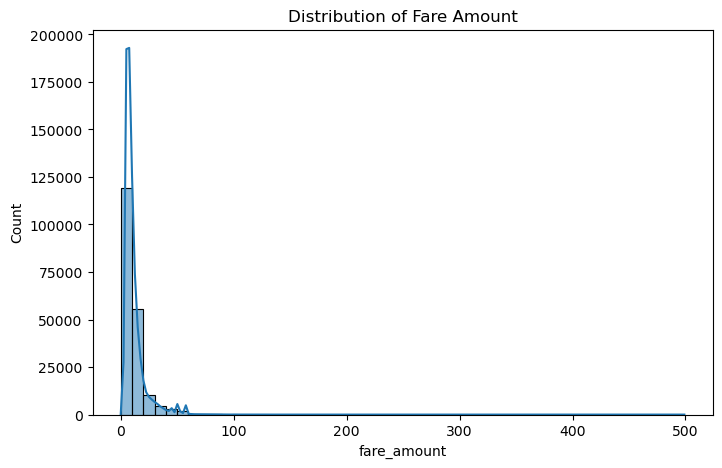

In [131]:
# Target Distribution

plt.figure(figsize=(8,5))
sns.histplot(df['fare_amount'], bins=50, kde=True)
plt.title("Distribution of Fare Amount")
plt.show()

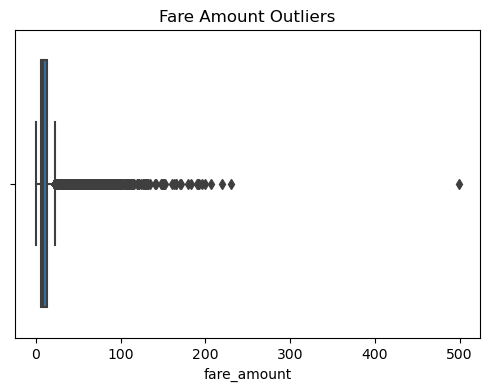

In [132]:
# Boxplot for outliers
plt.figure(figsize=(6,4))
sns.boxplot(x=df['fare_amount'])
plt.title("Fare Amount Outliers")
plt.show()

In [133]:
# Removing extreme values of fare

df = df[df['fare_amount'] < df['fare_amount'].quantile(0.99)]

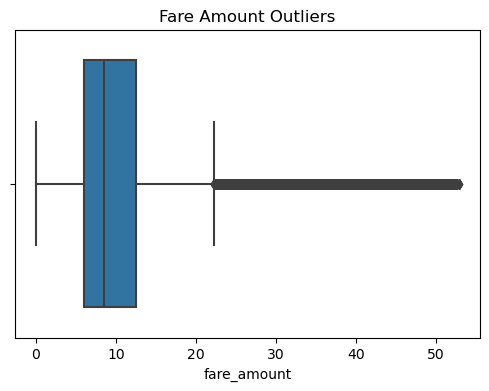

In [153]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['fare_amount'])
plt.title("Fare Amount Outliers")
plt.show()

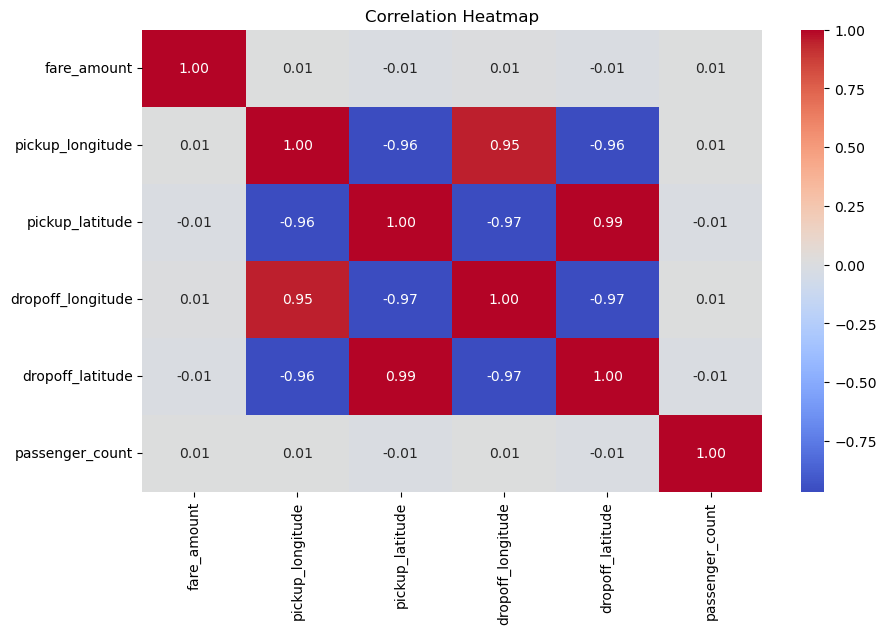

In [134]:
# Correlation heatmap

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

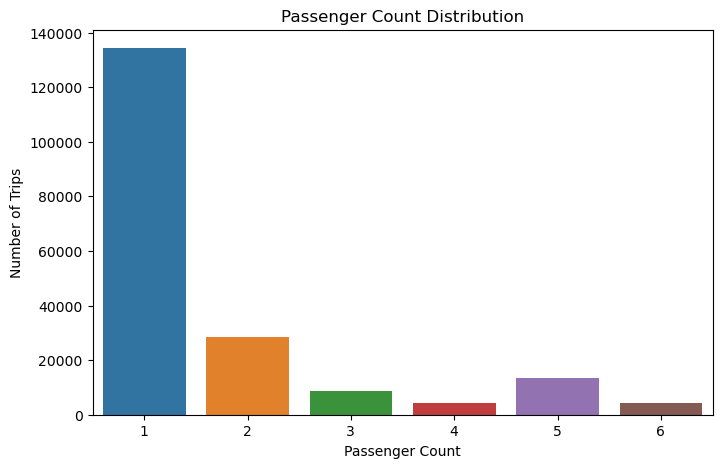

In [135]:
# Barplot of passenger counts
plt.figure(figsize=(8,5))
sns.countplot(x='passenger_count', data=df)
plt.title("Passenger Count Distribution")
plt.xlabel("Passenger Count")
plt.ylabel("Number of Trips")
plt.show()

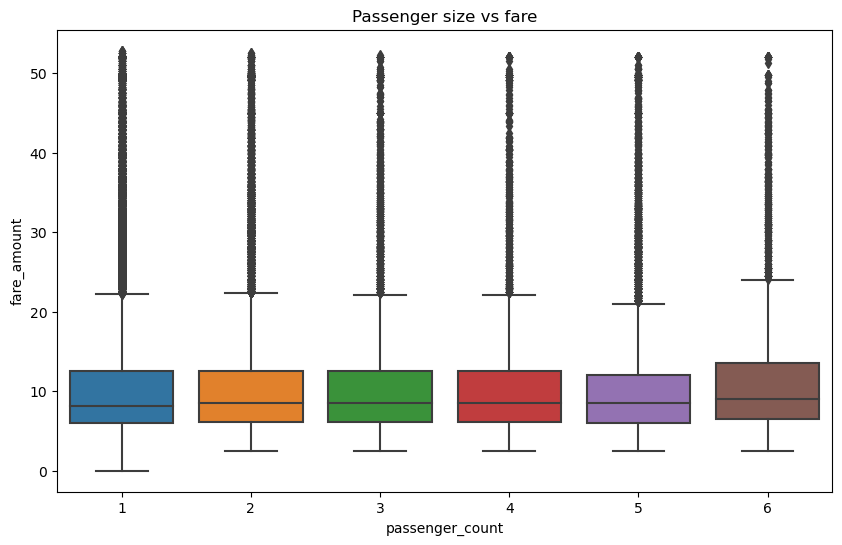

In [152]:
plt.figure(figsize= (10,6))
sns.boxplot(data= df, x= 'passenger_count', y= 'fare_amount')
plt.title("Passenger size vs fare")
plt.show()

### *Feature Engineering*

In [136]:
# Extract time features
df['hour'] = df['pickup_datetime'].dt.hour
df['day_of_week'] = df['pickup_datetime'].dt.dayofweek
df['month'] = df['pickup_datetime'].dt.month
df['year'] = df['pickup_datetime'].dt.year


In [137]:
# Weekend flag
df['is_weekend'] = df['day_of_week'].isin([5,6]).astype(int)

# Rush hour flag (example: 7–9 AM, 4–7 PM)
df['is_rush_hour'] = df['hour'].isin([7,8,9,16,17,18,19]).astype(int)

In [138]:
from geopy.distance import geodesic

def haversine_distance(row):
    pickup = (row['pickup_latitude'], row['pickup_longitude'])
    dropoff = (row['dropoff_latitude'], row['dropoff_longitude'])
    return geodesic(pickup, dropoff).km

df['distance_km'] = df.apply(haversine_distance, axis=1)

# Speed feature (fare per km or km per minute if dropoff time exists)
df['fare_per_km'] = df['fare_amount'] / (df['distance_km'] + 1e-3)

In [139]:
# Log transforming fares as they are skewed

df['fare_amount_log'] = np.log1p(df['fare_amount'])

In [140]:
# Compute correlations with target
corr_matrix = df.corr()

# Sort correlations with respect to fare_amount_log
target_corr = corr_matrix['fare_amount_log'].sort_values(ascending=False)

print("Feature correlations with fare_amount_log:")
print(target_corr)

Feature correlations with fare_amount_log:
fare_amount_log      1.000000
fare_amount          0.934897
year                 0.127098
fare_per_km          0.067022
distance_km          0.030842
month                0.030501
passenger_count      0.016683
day_of_week          0.011104
dropoff_longitude    0.008336
pickup_longitude     0.008313
is_weekend           0.002528
pickup_latitude     -0.006381
dropoff_latitude    -0.006726
hour                -0.016762
is_rush_hour        -0.025564
Name: fare_amount_log, dtype: float64


### *Feature Selection and Splitting*

In [141]:
# Keep features with correlation above threshold
threshold = 0.01
selected_features = target_corr[abs(target_corr) > threshold].index.tolist()

# Remove target itself
selected_features = [f for f in selected_features if f != 'fare_amount_log' and f != 'fare_amount' and f != 'fare_per_km']

print("Selected features:", selected_features)

Selected features: ['year', 'distance_km', 'month', 'passenger_count', 'day_of_week', 'hour', 'is_rush_hour']


In [142]:
# Final feature matrix
X = df[selected_features]
y = df['fare_amount_log']

In [ ]:
#Train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
#Importing libraries needed for model training
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

### *LINEAR REGRESSION MODEL*

In [145]:
# Linear Regression
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LinearRegression())
])
lr_pipeline.fit(X_train, y_train)
y_pred_train_lr = lr_pipeline.predict(X_train)
y_pred_test_lr = lr_pipeline.predict(X_test)

lr_train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train_lr))
lr_test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test_lr))
lr_train_r2 = r2_score(y_train, y_pred_train_lr)
lr_test_r2 = r2_score(y_test, y_pred_test_lr)

print("\nLinear Regression Performance:")
print(f"Train RMSE: {lr_train_rmse:.4f}, Train R2: {lr_train_r2:.4f}")
print(f"Test RMSE: {lr_test_rmse:.4f}, Test R2: {lr_test_r2:.4f}")


Linear Regression Performance:
Train RMSE: 0.5126, Train R2: 0.0206
Test RMSE: 0.5116, Test R2: 0.0187


### *RIDGE AND LASSO REGRESSION*

In [146]:
# Ridge Regression
ridge_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=1.0))
])
ridge_pipeline.fit(X_train, y_train)
y_pred_train_ridge = ridge_pipeline.predict(X_train)
y_pred_test_ridge = ridge_pipeline.predict(X_test)

ridge_train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train_ridge))
ridge_test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test_ridge))
ridge_train_r2 = r2_score(y_train, y_pred_train_ridge)
ridge_test_r2 = r2_score(y_test, y_pred_test_ridge)

print("\nRidge Regression Performance:")
print(f"Train RMSE: {ridge_train_rmse:.4f}, Train R2: {ridge_train_r2:.4f}")
print(f"Test RMSE: {ridge_test_rmse:.4f}, Test R2: {ridge_test_r2:.4f}")

# Lasso Regression
lasso_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(alpha=0.01))
])
lasso_pipeline.fit(X_train, y_train)
y_pred_train_lasso = lasso_pipeline.predict(X_train)
y_pred_test_lasso = lasso_pipeline.predict(X_test)

lasso_train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train_lasso))
lasso_test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test_lasso))
lasso_train_r2 = r2_score(y_train, y_pred_train_lasso)
lasso_test_r2 = r2_score(y_test, y_pred_test_lasso)

print("\nLasso Regression Performance:")
print(f"Train RMSE: {lasso_train_rmse:.4f}, Train R2: {lasso_train_r2:.4f}")
print(f"Test RMSE: {lasso_test_rmse:.4f}, Test R2: {lasso_test_r2:.4f}")


Ridge Regression Performance:
Train RMSE: 0.5126, Train R2: 0.0206
Test RMSE: 0.5116, Test R2: 0.0187

Lasso Regression Performance:
Train RMSE: 0.5131, Train R2: 0.0185
Test RMSE: 0.5119, Test R2: 0.0176


### *XGBOOST MODEL*

In [147]:
# XGBoost
xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb.fit(X_train, y_train)
y_pred_train_xgb = xgb.predict(X_train)
y_pred_test_xgb = xgb.predict(X_test)

xgb_train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train_xgb))
xgb_test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test_xgb))
xgb_train_r2 = r2_score(y_train, y_pred_train_xgb)
xgb_test_r2 = r2_score(y_test, y_pred_test_xgb)

print("\nXGBoost Performance:")
print(f"Train RMSE: {xgb_train_rmse:.4f}, Train R2: {xgb_train_r2:.4f}")
print(f"Test RMSE: {xgb_test_rmse:.4f}, Test R2: {xgb_test_r2:.4f}")


XGBoost Performance:
Train RMSE: 0.2189, Train R2: 0.8213
Test RMSE: 0.2339, Test R2: 0.7948


In [148]:
# Combine results into DataFrame
results_df = pd.DataFrame({
    "Linear Regression": {
        "Train RMSE": lr_train_rmse, "Train R2": lr_train_r2,
        "Test RMSE": lr_test_rmse, "Test R2": lr_test_r2
    },
    "Ridge Regression": {
        "Train RMSE": ridge_train_rmse, "Train R2": ridge_train_r2,
        "Test RMSE": ridge_test_rmse, "Test R2": ridge_test_r2
    },
    "Lasso Regression": {
        "Train RMSE": lasso_train_rmse, "Train R2": lasso_train_r2,
        "Test RMSE": lasso_test_rmse, "Test R2": lasso_test_r2
    },
    "XGBoost": {
        "Train RMSE": xgb_train_rmse, "Train R2": xgb_train_r2,
        "Test RMSE": xgb_test_rmse, "Test R2": xgb_test_r2
    }
})
results_df

,Linear Regression,Ridge Regression,Lasso Regression,XGBoost
Train RMSE,0.512587,0.512587,0.513129,0.218938
Train R2,0.020606,0.020606,0.018536,0.821324
Test RMSE,0.511587,0.511587,0.511881,0.233941
Test R2,0.018733,0.018733,0.017602,0.794808


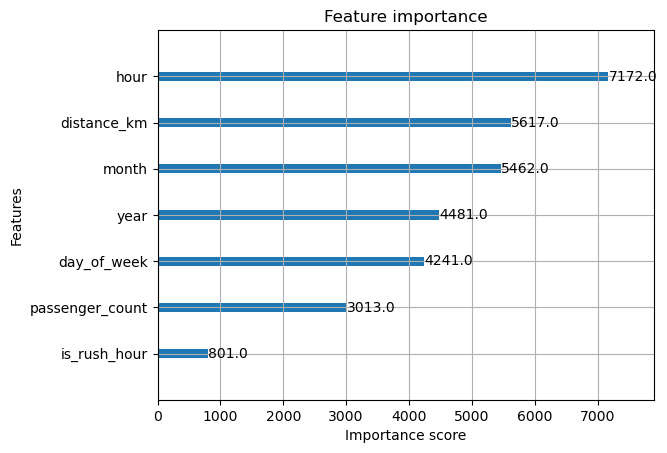

In [ ]:
#Plotitng which features contribute more to the training
import matplotlib.pyplot as plt
from xgboost import plot_importance

plot_importance(xgb, max_num_features=10)
plt.show()

### *HyperParameter Tuning*

In [150]:
param_grid = {
    'n_estimators': [200, 400, 600, 800],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7, 9],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'reg_alpha': [0, 0.1, 0.5, 1],
    'reg_lambda': [1, 1.5, 2]
}

In [151]:
from sklearn.model_selection import RandomizedSearchCV

xgb_base = XGBRegressor(random_state=42)

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid,
    n_iter=30,              # number of random combinations
    scoring='r2',
    cv=3,                   # 3-fold cross-validation
    verbose=1,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)
print("Best CV R2:", random_search.best_score_)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best Parameters: {'subsample': 0.6, 'reg_lambda': 1, 'reg_alpha': 0.5, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 0.6}
Best CV R2: 0.8023542379448564


In [154]:
# Training XGBoost with best parameters

xgb_tuned = random_search.best_estimator_

# Train and evaluate
y_pred_train_xgb = xgb_tuned.predict(X_train)
y_pred_test_xgb = xgb_tuned.predict(X_test)

xgb_train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train_xgb))
xgb_test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test_xgb))
xgb_train_r2 = r2_score(y_train, y_pred_train_xgb)
xgb_test_r2 = r2_score(y_test, y_pred_test_xgb)

print("\nTuned XGBoost Performance:")
print(f"Train RMSE: {xgb_train_rmse:.4f}, Train R2: {xgb_train_r2:.4f}")
print(f"Test RMSE: {xgb_test_rmse:.4f}, Test R2: {xgb_test_r2:.4f}")


Tuned XGBoost Performance:
Train RMSE: 0.2246, Train R2: 0.8119
Test RMSE: 0.2331, Test R2: 0.7964
